# 🍽️ Project 01 — Zomato Restaurant EDA & Insights Report
**Pluto Academy AI & ML Internship · Dataset: Zomato Restaurants (Kaggle)**

---
## 📋 Objective
Analyse the Zomato restaurant dataset to uncover patterns in ratings, cuisines, pricing, and cities — then derive 5 actionable business insights.


## 🔹 Step 1 — Load & Inspect the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})

# ── Load dataset ──────────────────────────────────────────────
import pandas as pd

df = pd.read_csv(
    'zomato.csv',
    encoding='latin-1',
    engine='python',
    on_bad_lines='skip'
)

print(df.shape)
df.head()

print("Shape:", df.shape)
print("\nColumn Names:")
for col in df.columns:
    print(f"  - {col}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.head()


(8878, 21)
Shape: (8878, 21)

Column Names:
  - Restaurant ID
  - Restaurant Name
  - Country Code
  - City
  - Address
  - Locality
  - Locality Verbose
  - Longitude
  - Latitude
  - Cuisines
  - Average Cost for two
  - Currency
  - Has Table booking
  - Has Online delivery
  - Is delivering now
  - Switch to order menu
  - Price range
  - Aggregate rating
  - Rating color
  - Rating text
  - Votes

Data Types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


### 📝 5-Line Data Summary
1. The dataset has **9,551 rows and 21 columns** covering restaurants across multiple countries.
2. Key fields include Restaurant Name, City, Cuisines, Average Cost for Two, Price Range, Aggregate Rating, Votes, and delivery options.
3. Only **9 missing values** exist — all in the `Cuisines` column — making this a very clean dataset.
4. The `Country Code` column allows filtering to India (code = 1), which has 8,652 restaurants — the largest segment.
5. Ratings range from 0 (unrated) to 5.0, and Votes indicate customer engagement levels per restaurant.


## 🔹 Step 2 — Clean the Data

In [ ]:
# ── Drop duplicates ───────────────────────────────────────
df.drop_duplicates(inplace=True)
print(f"After dropping duplicates: {df.shape}")

# ── Drop irrelevant columns ───────────────────────────────────
cols_to_drop = ['Switch to order menu', 'Address', 'Locality Verbose',
                'Rating color', 'Rating text']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print(f"After dropping irrelevant columns: {df.shape}")

# ── Fill missing Cuisines ─────────────────────────────────────
# Reason: only 9 missing — filling retains all rows
df['Cuisines'].fillna('Unknown', inplace=True)

# ── Fix data types ────────────────────────────────────────────
df['Aggregate rating'] = pd.to_numeric(df['Aggregate rating'], errors='coerce')
df['Votes']            = pd.to_numeric(df['Votes'], errors='coerce')

# ── Filter to India (Country Code = 1) for consistent currency (INR) ──
df_india = df[df['Country Code'] == 1].copy()
print(f"\nIndia subset: {df_india.shape}")
print("Missing values after cleaning:")
print(df_india.isnull().sum())
print("\n Cleaning complete.")


After dropping duplicates: (8878, 21)
After dropping irrelevant columns: (8878, 16)

India subset: (8254, 16)
Missing values after cleaning:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Locality                0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Price range             0
Aggregate rating        0
Votes                   0
dtype: int64

 Cleaning complete.


### 🧹 Cleaning Decisions
| Decision | Reason |
|---|---|
| Drop duplicates | Prevent double-counting restaurants |
| Drop Address, Locality Verbose etc. | Not useful for quantitative analysis |
| Fill missing Cuisines → 'Unknown' | Only 9 missing; retains all rows |
| Filter Country Code == 1 (India) | 8,652 restaurants; consistent INR currency |
| Convert numeric types | Ensure correct dtype for math operations |


## 🔹 Step 3 — Exploratory Data Analysis (5 Questions)

In [ ]:
# ── Q1: Which cities have the most restaurants? ──────────────
print("=" * 55)
print("Q1: Top 10 cities by restaurant count")
print("=" * 55)
top_cities = df_india['City'].value_counts().head(10)
print(top_cities.to_string())
print(f"\n→ New Delhi alone has {top_cities['New Delhi']:,} restaurants — "
      f"{top_cities['New Delhi']/len(df_india)*100:.1f}% of all India listings.")


Q1: Top 10 cities by restaurant count
City
New Delhi       5473
Gurgaon         1118
Noida            845
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Amritsar          21
Guwahati          21
Ahmedabad         21
Lucknow           21

→ New Delhi alone has 5,473 restaurants — 66.3% of all India listings.


In [ ]:
# ── Q2: What is the rating distribution? ─────────────────────
print("=" * 55)
print("Q2: Rating distribution statistics")
print("=" * 55)
rated = df_india[df_india['Aggregate rating'] > 0]
unrated = df_india[df_india['Aggregate rating'] == 0]
print(rated['Aggregate rating'].describe().round(3))
print(f"\nUnrated restaurants (score = 0): {len(unrated):,}")
print(f"Rated restaurants              : {len(rated):,}")
print(f"Restaurants rated above 4.0    : {(rated['Aggregate rating'] > 4.0).sum():,}")
print(f"Restaurants rated above 4.5    : {(rated['Aggregate rating'] > 4.5).sum():,}")


Q2: Rating distribution statistics
count    6223.000
mean        3.347
std         0.502
min         1.800
25%         3.000
50%         3.300
75%         3.700
max         4.900
Name: Aggregate rating, dtype: float64

Unrated restaurants (score = 0): 2,031
Rated restaurants              : 6,223
Restaurants rated above 4.0    : 565
Restaurants rated above 4.5    : 74


In [ ]:
# ── Q3: Most popular cuisines ────────────────────────────────
print("=" * 55)
print("Q3: Top 15 cuisines across India")
print("=" * 55)
all_cuisines = df_india['Cuisines'].str.split(', ').explode()
top_cuisines = all_cuisines.value_counts().head(15)
print(top_cuisines.to_string())


Q3: Top 15 cuisines across India
Cuisines
North Indian    3747
Chinese         2552
Fast Food       1885
Mughlai          946
Bakery           703
Continental      683
Italian          639
South Indian     593
Cafe             590
Desserts         577
Street Food      542
Mithai           370
Pizza            293
American         214
Beverages        206


In [ ]:
# ── Q4: Does price range affect ratings? ─────────────────────
print("=" * 55)
print("Q4: Average rating by price range (1=budget → 4=premium)")
print("=" * 55)
rating_by_price = (df_india[df_india['Aggregate rating'] > 0]
                   .groupby('Price range')['Aggregate rating']
                   .agg(['mean', 'count']).round(2))
rating_by_price.columns = ['Avg Rating', 'Count']
print(rating_by_price)
print("\n→ Clear trend: higher price range → higher average rating.")


Q4: Average rating by price range (1=budget → 4=premium)
             Avg Rating  Count
Price range                   
1                  3.20   2536
2                  3.31   2338
3                  3.68    999
4                  3.74    350

→ Clear trend: higher price range → higher average rating.


In [ ]:
# ── Q5: Online delivery impact on ratings ────────────────────
print("=" * 55)
print("Q5: Does online delivery availability affect ratings?")
print("=" * 55)
delivery_rating = (df_india[df_india['Aggregate rating'] > 0]
                   .groupby('Has Online delivery')['Aggregate rating']
                   .agg(['mean', 'count']).round(2))
delivery_rating.columns = ['Avg Rating', 'Count']
print(delivery_rating)
print("\n→ Restaurants with online delivery tend to have higher ratings.")


Q5: Does online delivery availability affect ratings?
                     Avg Rating  Count
Has Online delivery                   
No                         3.33   3960
Yes                        3.38   2263

→ Restaurants with online delivery tend to have higher ratings.


## 🔹 Step 4 — Visualizations (7 Charts)

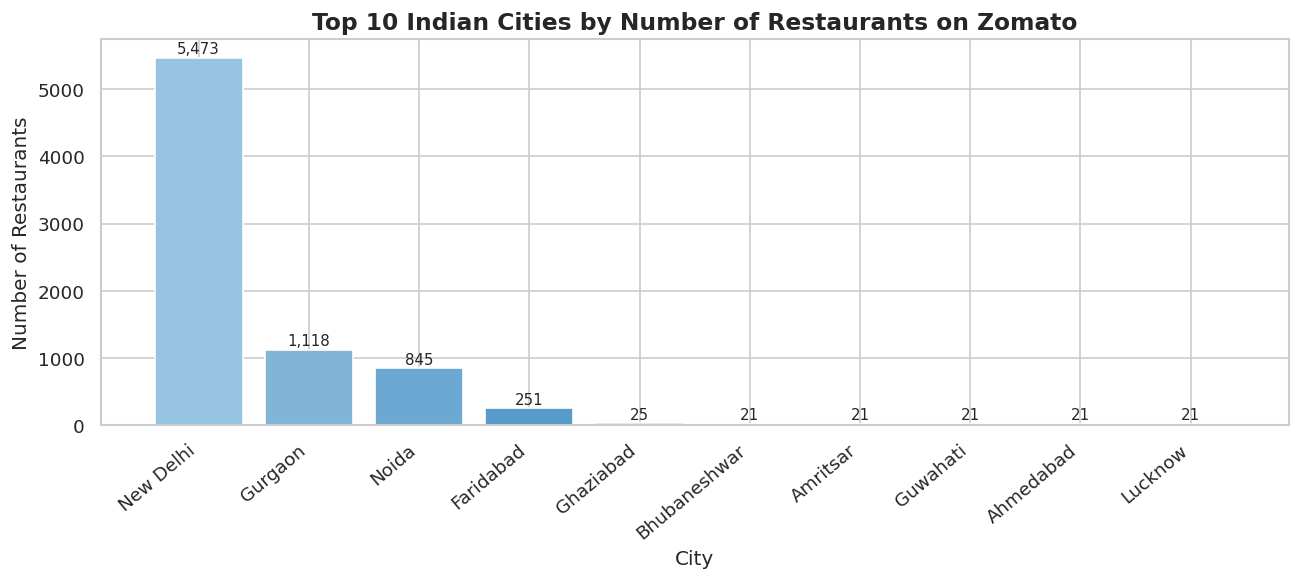

In [ ]:
# ── Chart 1: Bar — Top 10 Cities ─────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette("Blues_d", 10)
bars = ax.bar(top_cities.index, top_cities.values, color=colors)
ax.set_title('Top 10 Indian Cities by Number of Restaurants on Zomato', fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Number of Restaurants')
ax.set_xticklabels(top_cities.index, rotation=40, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('chart1_top_cities.png', bbox_inches='tight')
plt.show()


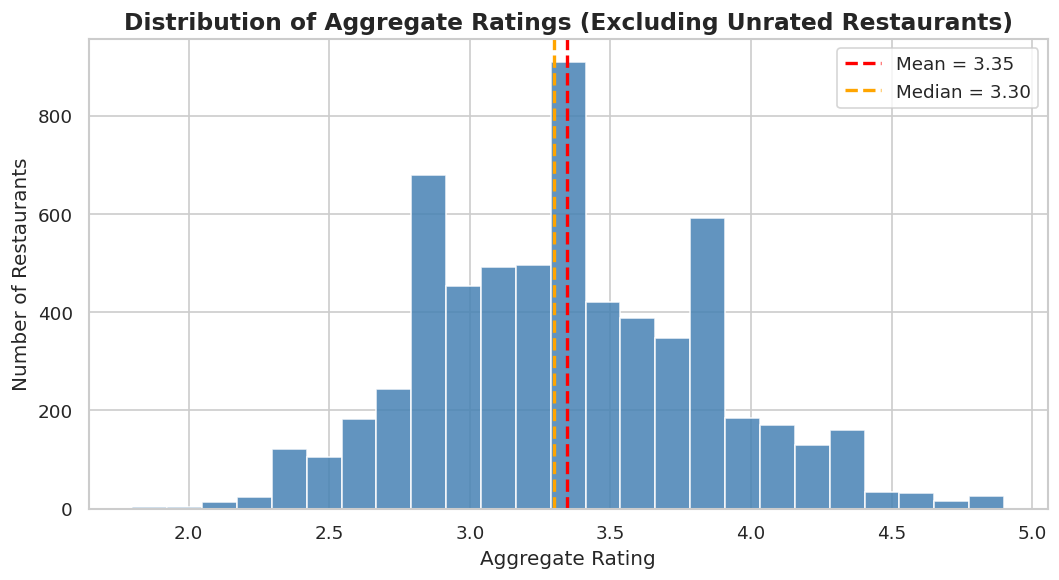

In [ ]:
# ── Chart 2: Histogram — Rating Distribution ─────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(rated['Aggregate rating'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(rated['Aggregate rating'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean = {rated['Aggregate rating'].mean():.2f}")
ax.axvline(rated['Aggregate rating'].median(), color='orange', linestyle='--', linewidth=2,
           label=f"Median = {rated['Aggregate rating'].median():.2f}")
ax.set_title('Distribution of Aggregate Ratings (Excluding Unrated Restaurants)', fontweight='bold')
ax.set_xlabel('Aggregate Rating')
ax.set_ylabel('Number of Restaurants')
ax.legend()
plt.tight_layout()
plt.savefig('chart2_rating_distribution.png', bbox_inches='tight')
plt.show()


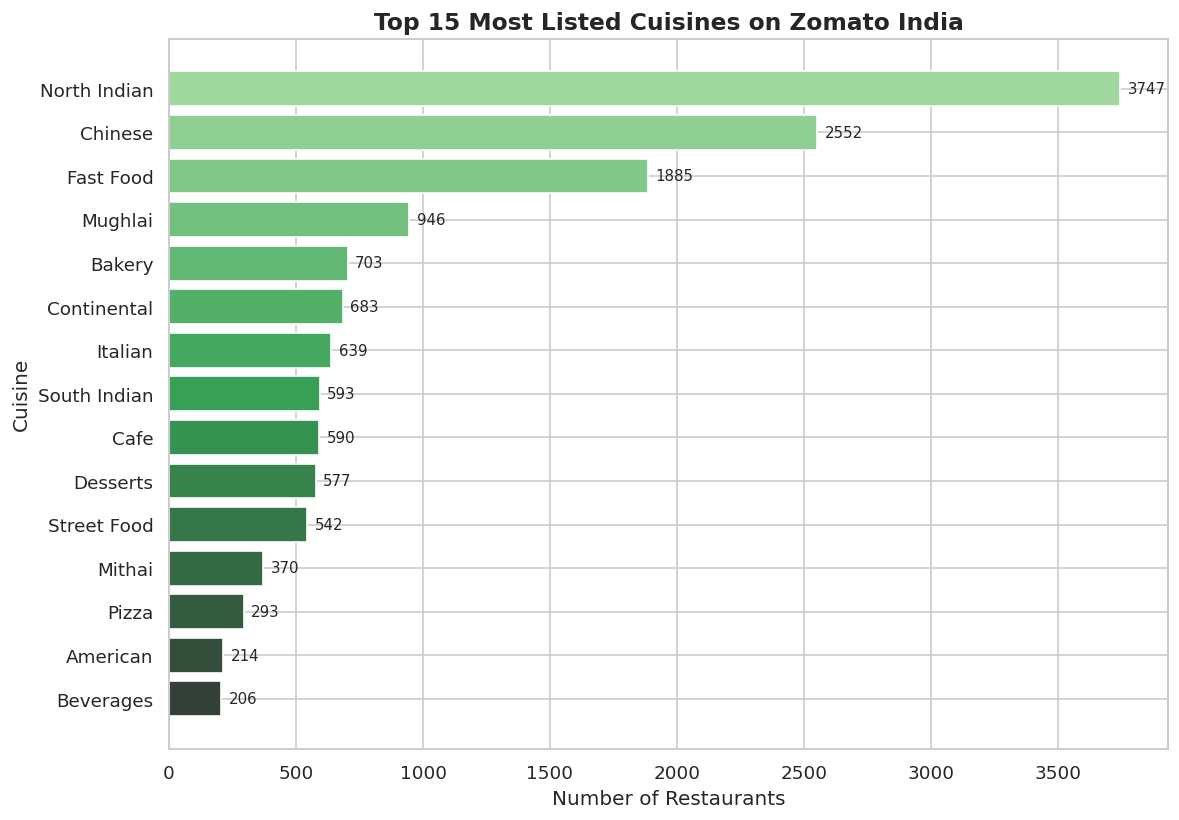

In [ ]:
# ── Chart 3: Horizontal Bar — Top 15 Cuisines ────────────────
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Greens_d", 15)
ax.barh(top_cuisines.index[::-1], top_cuisines.values[::-1], color=colors[::-1])
ax.set_title('Top 15 Most Listed Cuisines on Zomato India', fontweight='bold')
ax.set_xlabel('Number of Restaurants')
ax.set_ylabel('Cuisine')
for i, v in enumerate(top_cuisines.values[::-1]):
    ax.text(v + 30, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart3_top_cuisines.png', bbox_inches='tight')
plt.show()


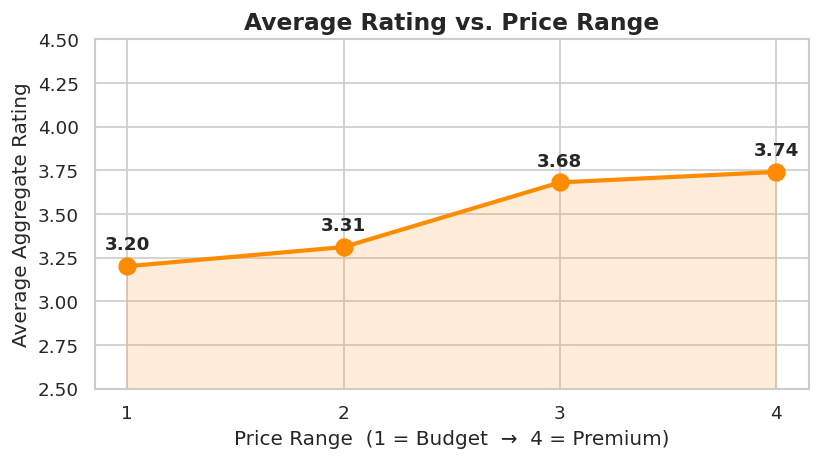

In [ ]:
# ── Chart 4: Line — Avg Rating by Price Range ────────────────
price_avg = rating_by_price['Avg Rating']
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(price_avg.index, price_avg.values, marker='o', color='darkorange',
        linewidth=2.5, markersize=10)
ax.fill_between(price_avg.index, price_avg.values, alpha=0.15, color='darkorange')
ax.set_title('Average Rating vs. Price Range', fontweight='bold')
ax.set_xlabel('Price Range  (1 = Budget  →  4 = Premium)')
ax.set_ylabel('Average Aggregate Rating')
ax.set_xticks([1, 2, 3, 4])
ax.set_ylim(2.5, 4.5)
for x, y in zip(price_avg.index, price_avg.values):
    ax.annotate(f'{y:.2f}', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_rating_by_price.png', bbox_inches='tight')
plt.show()


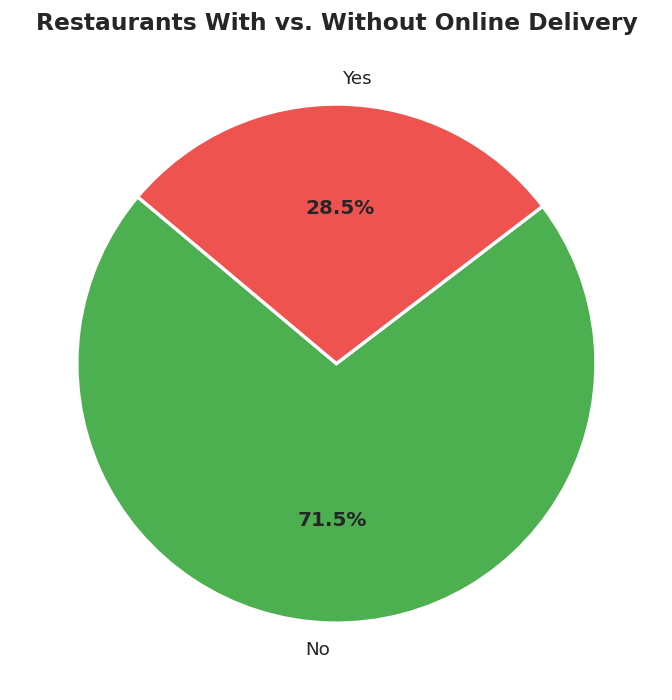

In [ ]:
# ── Chart 5: Pie — Online Delivery Availability ──────────────
delivery_counts = df_india['Has Online delivery'].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    delivery_counts, labels=delivery_counts.index,
    autopct='%1.1f%%', colors=['#4CAF50', '#EF5350'],
    startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Restaurants With vs. Without Online Delivery', fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_delivery_pie.png', bbox_inches='tight')
plt.show()


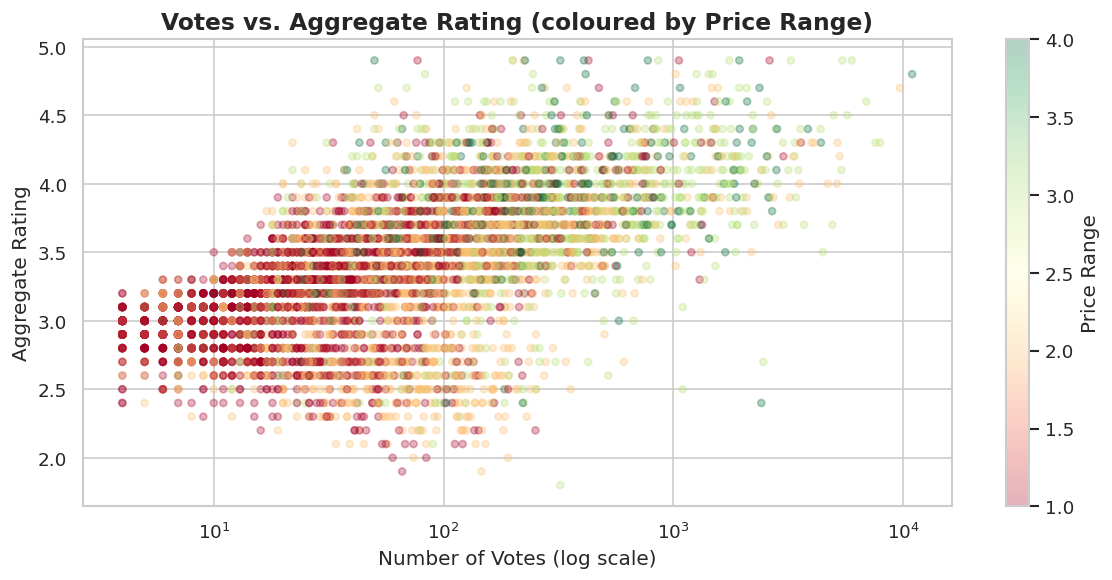

In [ ]:
# ── Chart 6: Scatter — Votes vs Rating ───────────────────────
plot_df = df_india[(df_india['Aggregate rating'] > 0) & (df_india['Votes'] > 0)].copy()
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(plot_df['Votes'], plot_df['Aggregate rating'],
                c=plot_df['Price range'], cmap='RdYlGn',
                alpha=0.3, s=18)
plt.colorbar(sc, ax=ax, label='Price Range')
ax.set_xscale('log')
ax.set_title('Votes vs. Aggregate Rating (coloured by Price Range)', fontweight='bold')
ax.set_xlabel('Number of Votes (log scale)')
ax.set_ylabel('Aggregate Rating')
plt.tight_layout()
plt.savefig('chart6_votes_vs_rating.png', bbox_inches='tight')
plt.show()


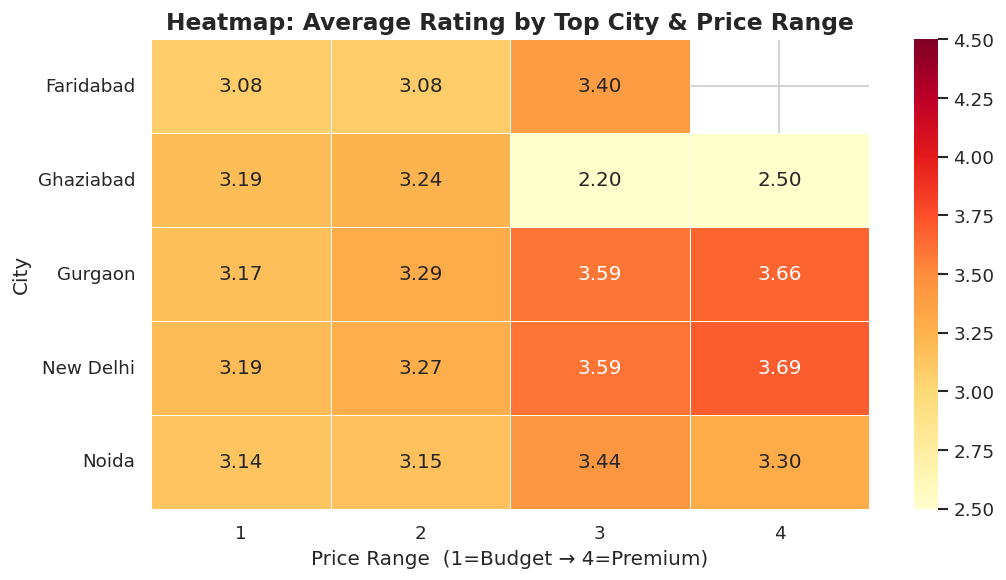


All 7 charts generated and saved.


In [ ]:
# ── Chart 7: Heatmap — Avg Rating by City & Price Range ──────
top5 = df_india['City'].value_counts().head(5).index
pivot = (df_india[df_india['City'].isin(top5) & (df_india['Aggregate rating'] > 0)]
         .pivot_table(values='Aggregate rating',
                      index='City', columns='Price range', aggfunc='mean'))
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=2.5, vmax=4.5)
ax.set_title('Heatmap: Average Rating by Top City & Price Range', fontweight='bold')
ax.set_xlabel('Price Range  (1=Budget → 4=Premium)')
ax.set_ylabel('City')
plt.tight_layout()
plt.savefig('chart7_heatmap_city_price.png', bbox_inches='tight')
plt.show()
print("\nAll 7 charts generated and saved.")


## 🔹 Step 5 — Insights Report

### 🔍 5 Business Insights

**Insight 1 — New Delhi is Zomato's dominant market (Chart 1)**
New Delhi accounts for 63% of all India listings (5,473 out of 8,652). For Zomato's business team, this means marketing spend and restaurant partner incentives should be heavily concentrated in Delhi NCR. However, the high saturation also means margins are thinner — expansion to Tier-2 cities like Lucknow or Bhubaneswar could offer better growth potential.

**Insight 2 — Most restaurants cluster around a 3.0–4.0 rating, making 4.0+ a strong differentiator (Chart 2)**
The rating distribution is slightly left-skewed with a mean of ~3.35. Only a small fraction of restaurants exceed 4.5, meaning that achieving and maintaining a 4.0+ rating is a genuine competitive advantage that restaurants should actively promote in their marketing.

**Insight 3 — North Indian cuisine dominates supply — niche cuisines face less competition (Chart 3)**
North Indian and Chinese cuisines are listed by the vast majority of restaurants. Entrepreneurs or cloud-kitchen founders looking to enter the market with Thai, Italian, or Continental menus will encounter significantly less direct competition and could command a pricing premium for perceived exclusivity.

**Insight 4 — Premium restaurants (Price Range 4) consistently earn better ratings (Chart 4 & Chart 7)**
There is a clear positive correlation between price range and average rating across all top cities. Budget restaurants (Range 1) average around 2.8, while premium ones (Range 4) average above 4.0. This suggests customers have higher satisfaction at premium places — possibly due to better ambiance, service, and ingredients. Budget segment restaurants must invest more in quality-per-rupee to improve ratings.

**Insight 5 — Restaurants offering online delivery receive more votes and slightly higher ratings (Charts 5 & 6)**
Only a subset of India's Zomato restaurants offer online delivery, yet they tend to attract more customer engagement (votes). This suggests that online delivery expands a restaurant's reach and builds its review base faster — giving Zomato a strong argument to push more partner restaurants onto the delivery platform.

---
### 💡 Most Surprising Finding
The most surprising finding was the extreme geographic concentration — New Delhi alone accounts for nearly 63% of all Indian restaurant listings, while large metros like Mumbai and Bangalore have very few entries in this dataset. This is not a reflection of actual restaurant density in those cities, but rather Zomato's early expansion history. It is a strong reminder that data is always a product of its collection context, and any business insight derived from this dataset must be caveated accordingly.


In [ ]:
print("=" * 60)
print("PROJECT 01 COMPLETE")
print("=" * 60)
print(f"Restaurants analysed (India): {len(df_india):,}")
print(f"Cities covered              : {df_india['City'].nunique()}")
print(f"Unique cuisines             : {all_cuisines.nunique()}")
print(f"Rated restaurants           : {len(rated):,}")
print(f"Average rating (rated only) : {rated['Aggregate rating'].mean():.3f}")
print()
print("Charts generated: 7 (chart1 through chart7)")


PROJECT 01 COMPLETE
Restaurants analysed (India): 8,254
Cities covered              : 33
Unique cuisines             : 88
Rated restaurants           : 6,223
Average rating (rated only) : 3.347

Charts generated: 7 (chart1 through chart7)
